In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
import math
def sigmoid(x):
    return (1/(1+np.exp(-x)))
def sigmoid_derivative(input_x):
    return input_x*(1- input_x)
    
def activation_function(val):
    output = sigmoid_function(val)
    return derivative_sigmoid(output)
    
activation_function(10)

4.5395807735907655e-05

In [28]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])

y = np.array([[0], [1], [1], [0]])

In [29]:
input_size = 2
hidden_size = 3
output_size = 1
learning_rate = 0.1


W1 = np.random.uniform(size=(input_size, hidden_size))
b1 = np.zeros((1, hidden_size))
W2 = np.random.uniform(size=(hidden_size, output_size))
b2 = np.zeros((1, output_size))

--- Training Started ---
Epoch     0: Loss 0.279774
Epoch  1000: Loss 0.249891
Epoch  2000: Loss 0.249476
Epoch  3000: Loss 0.245620
Epoch  4000: Loss 0.215207
Epoch  5000: Loss 0.151844
Epoch  6000: Loss 0.047389
Epoch  7000: Loss 0.016289
Epoch  8000: Loss 0.008733
Epoch  9000: Loss 0.005752
Epoch 10000: Loss 0.004221
--- Training Finished ---

Final Model Predictions:
[[0.06557003]
 [0.937161  ]
 [0.93732728]
 [0.06862044]]


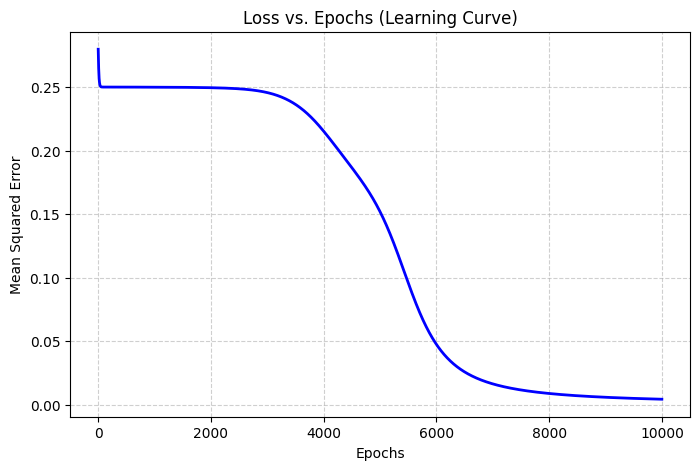

In [30]:
loss_history = []


epochs = 10000
print("--- Training Started ---")

for epoch in range(epochs):
    
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)
    
   
    error = y - a2
    loss = np.mean(np.square(error)) 
    loss_history.append(loss)
    
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5}: Loss {loss:.6f}")
    
   
    d_a2 = error * sigmoid_derivative(a2)
    error_hidden = d_a2.dot(W2.T)
    d_a1 = error_hidden * sigmoid_derivative(a1)
    
    
    W2 += a1.T.dot(d_a2) * learning_rate
    b2 += np.sum(d_a2, axis=0, keepdims=True) * learning_rate
    W1 += X.T.dot(d_a1) * learning_rate
    b1 += np.sum(d_a1, axis=0, keepdims=True) * learning_rate

print(f"Epoch 10000: Loss {loss:.6f}")
print("--- Training Finished ---")


print("\nFinal Model Predictions:")
print(a2)


plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Loss vs. Epochs (Learning Curve)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()